# Preprocessing Analysis: Opinion Page Splitting Thresholds

Determine optimal cutoffs for splitting long opinions into overlapping pages so that:
1. Opinion text + v318 instructions fit within Sonnet 4.6's 1M input token context window
2. Expected output (cited cases) stays within the 64K max output token limit
3. Overlap between pages prevents missing citations at page boundaries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load token usage from 04012026 Sonnet 4.6 run (8 test cases)
raw = pd.read_csv("../experiments_04012026/data/output/v318/claude-sonnet-4-6/raw_results.csv")
parsed = pd.read_csv("../experiments_04012026/data/output/v318/claude-sonnet-4-6/parsed_results.csv")
cited_per = parsed.groupby("citing_cluster_id").size().reset_index(name="num_cited_cases")
raw = raw.merge(cited_per, on="citing_cluster_id", how="left")

# Get opinion text lengths for those 8 cases
with open("../experiments_04012026/data/input/example.txt") as f:
    example_ids = [x.strip() for x in f.read().split(",") if x.strip()]

text_lengths = []
for cid in example_ids:
    path = f"../experiments_04012026/data/input/citing/{cid}.txt"
    if os.path.exists(path):
        text_lengths.append({"citing_cluster_id": int(cid), "text_length": os.path.getsize(path)})
text_df = pd.DataFrame(text_lengths)
raw = raw.merge(text_df, on="citing_cluster_id", how="left")

print("=== Sonnet 4.6 Token Usage (04012026, 8 test cases) ===")
raw[["citing_cluster_id", "text_length", "input_tokens", "output_tokens", "num_cited_cases"]]

=== Sonnet 4.6 Token Usage (04012026, 8 test cases) ===


,citing_cluster_id,text_length,input_tokens,output_tokens,num_cited_cases
0,117849,23253,16087,4881,23
1,110420,36184,19161,5817,28
2,103543,18821,14697,6113,28
3,110274,32310,19174,7718,37
4,7774813,13454,13339,3971,17
5,101625,44321,19686,4233,18
6,725046,31169,18240,9113,40
7,110360,120348,40366,15051,61


In [2]:
# Calibrate chars-per-token ratio and output tokens per cited case
raw["chars_per_input_token"] = (raw["text_length"] + 33300) / raw["input_tokens"]  # +33K for instructions
raw["output_tokens_per_cite"] = raw["output_tokens"] / raw["num_cited_cases"]

print("=== Calibration ===")
print(f"Chars per input token: mean={raw['chars_per_input_token'].mean():.2f}, min={raw['chars_per_input_token'].min():.2f}, max={raw['chars_per_input_token'].max():.2f}")
print(f"Output tokens per cited case: mean={raw['output_tokens_per_cite'].mean():.0f}, min={raw['output_tokens_per_cite'].min():.0f}, max={raw['output_tokens_per_cite'].max():.0f}")
print()
print("NOTE: Calibration based on only 8 test cases (max 61 cited cases).")
print("Cases with 200+ authorities may produce more verbose output per cite.")
print("Using 300 tokens/cite as safety margin for high-authority cases.")
print()

# Key constants derived from calibration
CHARS_PER_TOKEN = 3.5  # conservative (use lower bound)
INSTRUCTION_CHARS = 33300
INSTRUCTION_TOKENS = INSTRUCTION_CHARS / CHARS_PER_TOKEN
# 250 tokens/cite was the observed max from 8 small cases — use 300 for safety
# at scale with 200+ authorities, output per cite may be higher
OUTPUT_TOKENS_PER_CITE = 300

print(f"Using: {CHARS_PER_TOKEN} chars/token, {INSTRUCTION_TOKENS:.0f} instruction tokens, {OUTPUT_TOKENS_PER_CITE} output tokens/cite")

=== Calibration ===
Chars per input token: mean=3.61, min=3.42, max=3.94
Output tokens per cited case: mean=224, min=208, max=247

NOTE: Calibration based on only 8 test cases (max 61 cited cases).
Cases with 200+ authorities may produce more verbose output per cite.
Using 300 tokens/cite as safety margin for high-authority cases.

Using: 3.5 chars/token, 9514 instruction tokens, 300 output tokens/cite


=== Page Split Cutoff Derivation ===
Regression: auths = 0.000574 * text_len + 6.53
  correlation: 0.878
  P95 residual: +29 auths -> cutoff:   199,550 chars
  P99 residual: +61 auths -> cutoff:   144,158 chars

  P95 (~200K)         : 1 unsplit cases exceed 150 auths, 10 cases split unnecessarily
  P99 (~144K)         : 0 unsplit cases exceed 150 auths, 36 cases split unnecessarily

  Worst outlier: cluster 248512 — 165,481 chars, 379 auths (+277 vs prediction)

  Selected cutoff: 145,000 chars (rounded P99)



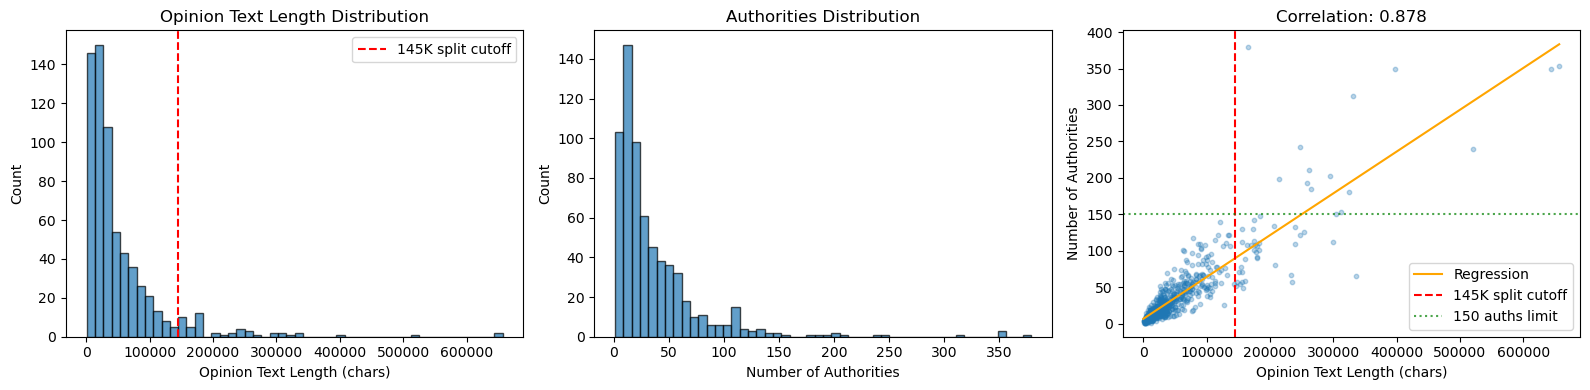

=== Percentile Analysis ===
P50 — text_length:    29,955 chars (  8,559 tokens)  |  authorities:    22 (  6,600 est. output tokens)
P75 — text_length:    64,818 chars ( 18,519 tokens)  |  authorities:    47 ( 14,100 est. output tokens)
P80 — text_length:    76,927 chars ( 21,979 tokens)  |  authorities:    54 ( 16,200 est. output tokens)
P85 — text_length:    92,159 chars ( 26,331 tokens)  |  authorities:    64 ( 19,200 est. output tokens)
P90 — text_length:   114,170 chars ( 32,620 tokens)  |  authorities:    82 ( 24,600 est. output tokens)
P95 — text_length:   174,681 chars ( 49,909 tokens)  |  authorities:   110 ( 33,000 est. output tokens)
P99 — text_length:   316,874 chars ( 90,535 tokens)  |  authorities:   223 ( 66,780 est. output tokens)


In [3]:
# Full dataset distribution from 04022026 (661 cases, all circuits)
full_df = pd.read_csv("../experiments_04022026/data/citing_metadata.csv")

# Determine the page split cutoff from the output token constraint.
# Constraint: each page must produce <= MAX output tokens.
# At 300 tokens/cite, we can handle at most ~213 cites per page.
# Conservative target: 150 cites per page (45K tokens, within 64K).
MAX_CITED_PER_PAGE = 150

# Approach: fit a linear regression of num_authorities ~ text_length,
# then find the text_length at which predicted + P99 residual = 150.
# This accounts for the variance in citation density across cases.
coeffs = np.polyfit(full_df["opinion_text_length"], full_df["num_authorities"], 1)
slope, intercept = coeffs
full_df["predicted_auths"] = slope * full_df["opinion_text_length"] + intercept
full_df["residual"] = full_df["num_authorities"] - full_df["predicted_auths"]

p95_residual = full_df["residual"].quantile(0.95)
p99_residual = full_df["residual"].quantile(0.99)

# At the cutoff: slope * cutoff + intercept + residual_margin = MAX_CITED_PER_PAGE
cutoff_p95 = (MAX_CITED_PER_PAGE - intercept - p95_residual) / slope
cutoff_p99 = (MAX_CITED_PER_PAGE - intercept - p99_residual) / slope

print("=== Page Split Cutoff Derivation ===")
print(f"Regression: auths = {slope:.6f} * text_len + {intercept:.2f}")
print(f"  correlation: {full_df['opinion_text_length'].corr(full_df['num_authorities']):.3f}")
print(f"  P95 residual: {p95_residual:+.0f} auths -> cutoff: {cutoff_p95:>9,.0f} chars")
print(f"  P99 residual: {p99_residual:+.0f} auths -> cutoff: {cutoff_p99:>9,.0f} chars")
print()

# Compare cutoff options: misses (unsplit cases > 150 auths) vs unnecessary splits
for label, cutoff in [("P95 (~200K)", cutoff_p95), ("P99 (~144K)", cutoff_p99)]:
    under = full_df[full_df["opinion_text_length"] <= cutoff]
    exceeds = under[under["num_authorities"] > MAX_CITED_PER_PAGE]
    above = full_df[full_df["opinion_text_length"] > cutoff]
    unnecessary = above[above["num_authorities"] <= MAX_CITED_PER_PAGE]
    print(f"  {label:20s}: {len(exceeds)} unsplit cases exceed {MAX_CITED_PER_PAGE} auths, {len(unnecessary)} cases split unnecessarily")

# The extreme outlier driving the gap between P95 and P99:
outlier = full_df.loc[full_df["residual"].idxmax()]
print(f"\n  Worst outlier: cluster {int(outlier['cluster_id'])} — {int(outlier['opinion_text_length']):,} chars, "
      f"{int(outlier['num_authorities'])} auths ({int(outlier['residual']):+d} vs prediction)")

# Use P99 cutoff (rounded to 145K) to guarantee no unsplit case exceeds 150 auths
SPLIT_CUTOFF_CHARS = 145_000
print(f"\n  Selected cutoff: {SPLIT_CUTOFF_CHARS:,} chars (rounded P99)")
print()

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(full_df["opinion_text_length"], bins=50, edgecolor="black", alpha=0.7)
axes[0].axvline(SPLIT_CUTOFF_CHARS, color="red", linestyle="--", label=f"{SPLIT_CUTOFF_CHARS // 1000}K split cutoff")
axes[0].set_xlabel("Opinion Text Length (chars)")
axes[0].set_ylabel("Count")
axes[0].set_title("Opinion Text Length Distribution")
axes[0].legend()

axes[1].hist(full_df["num_authorities"], bins=50, edgecolor="black", alpha=0.7)
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].set_xlabel("Number of Authorities")
axes[1].set_ylabel("Count")
axes[1].set_title("Authorities Distribution")

axes[2].scatter(full_df["opinion_text_length"], full_df["num_authorities"], alpha=0.3, s=10)
xs = np.linspace(0, full_df["opinion_text_length"].max(), 100)
axes[2].plot(xs, slope * xs + intercept, color="orange", linewidth=1.5, label="Regression")
axes[2].axvline(SPLIT_CUTOFF_CHARS, color="red", linestyle="--", label=f"{SPLIT_CUTOFF_CHARS // 1000}K split cutoff")
axes[2].axhline(MAX_CITED_PER_PAGE, color="green", linestyle=":", alpha=0.7, label=f"{MAX_CITED_PER_PAGE} auths limit")
axes[2].set_xlabel("Opinion Text Length (chars)")
axes[2].set_ylabel("Number of Authorities")
axes[2].set_title(f"Correlation: {full_df['opinion_text_length'].corr(full_df['num_authorities']):.3f}")
axes[2].legend()

plt.tight_layout()
plt.show()

# Percentile analysis
print("=== Percentile Analysis ===")
for p in [50, 75, 80, 85, 90, 95, 99]:
    tl = full_df["opinion_text_length"].quantile(p / 100)
    na = full_df["num_authorities"].quantile(p / 100)
    print(f"P{p:2d} — text_length: {tl:>9,.0f} chars ({tl/CHARS_PER_TOKEN:>7,.0f} tokens)  |  authorities: {na:>5.0f} ({na * OUTPUT_TOKENS_PER_CITE:>7,.0f} est. output tokens)")

In [6]:
# Apply the derived cutoff to determine page splitting
# SPLIT_CUTOFF_CHARS = 145,000 (from P99 regression analysis above)
# Opinions longer than this get split into overlapping pages.

MAX_OUTPUT_TOKENS = 64_000
PAGE_SIZE_CHARS = SPLIT_CUTOFF_CHARS  # 145,000 chars
OVERLAP_CHARS = 20_000

print("=== Model Limits ===")
print(f"Context window:     1,000,000 tokens")
print(f"Max output tokens:     64,000 tokens")
print(f"Output tokens/cite:       ~{OUTPUT_TOKENS_PER_CITE} tokens (conservative)")
print(f"Max cited per call:       ~{MAX_OUTPUT_TOKENS // OUTPUT_TOKENS_PER_CITE} cases (hard limit)")
print()
print("=== Selected Thresholds ===")
print(f"Page size:       {PAGE_SIZE_CHARS:>9,} chars (~{PAGE_SIZE_CHARS / CHARS_PER_TOKEN:,.0f} tokens)")
print(f"Overlap:         {OVERLAP_CHARS:>9,} chars (~{OVERLAP_CHARS / CHARS_PER_TOKEN:,.0f} tokens)")
print(f"Target auths/page:     ~{MAX_CITED_PER_PAGE} (→ ~{MAX_CITED_PER_PAGE * OUTPUT_TOKENS_PER_CITE:,} output tokens)")
print()

# Impact analysis
needs_split = full_df[full_df["opinion_text_length"] > PAGE_SIZE_CHARS]
no_split = full_df[full_df["opinion_text_length"] <= PAGE_SIZE_CHARS]
print(f"Cases needing split: {len(needs_split)}/{len(full_df)} ({100 * len(needs_split) / len(full_df):.1f}%)")
print(f"Cases not split:     {len(no_split)}/{len(full_df)} ({100 * len(no_split) / len(full_df):.1f}%)")
print()

# Pages per case distribution
step = PAGE_SIZE_CHARS - OVERLAP_CHARS
def compute_pages(text_len):
    if text_len <= PAGE_SIZE_CHARS:
        return 1
    return max(2, int(np.ceil((text_len - OVERLAP_CHARS) / step)))

full_df["est_pages"] = full_df["opinion_text_length"].apply(compute_pages)
print("Estimated pages per case:")
print(full_df["est_pages"].value_counts().sort_index().to_string())
print(f"\nTotal API calls for all {len(full_df)} cases: {full_df['est_pages'].sum()} (vs {len(full_df)} without splitting)")
print()

# Per-page density check: flag pages that may exceed output limit
# Use per-case chars/auth ratio to estimate worst-case auths per page
print("=== Per-Case Density Check ===")
full_df["chars_per_auth"] = full_df["opinion_text_length"] / full_df["num_authorities"]
full_df["est_max_auths_per_page"] = PAGE_SIZE_CHARS / full_df["chars_per_auth"]
dense_cases = full_df[full_df["est_max_auths_per_page"] > MAX_CITED_PER_PAGE]
print(f"Cases where a single {PAGE_SIZE_CHARS // 1000}K page could exceed {MAX_CITED_PER_PAGE} auths: {len(dense_cases)}/{len(full_df)}")
if len(dense_cases) > 0:
    print("These cases may need smaller page sizes or per-page authority checks:")
    print(dense_cases[["cluster_id", "court", "opinion_text_length", "num_authorities", "chars_per_auth", "est_max_auths_per_page"]].sort_values("est_max_auths_per_page", ascending=False).head(20).to_string(index=False))
print()

# Show the cases that need splitting
if len(needs_split) > 0:
    print("Cases that need splitting:")
    print(needs_split[["cluster_id", "court", "opinion_text_length", "num_authorities"]].sort_values("opinion_text_length", ascending=False).to_string(index=False))
print()

# Deduplication note
print("=== Post-Processing: Deduplication ===")
print("When merging results from overlapping pages, citations appearing in multiple pages must be deduplicated.")

=== Model Limits ===
Context window:     1,000,000 tokens
Max output tokens:     64,000 tokens
Output tokens/cite:       ~300 tokens (conservative)
Max cited per call:       ~213 cases (hard limit)

=== Selected Thresholds ===
Page size:         145,000 chars (~41,429 tokens)
Overlap:            20,000 chars (~5,714 tokens)
Target auths/page:     ~150 (→ ~45,000 output tokens)

Cases needing split: 51/661 (7.7%)
Cases not split:     610/661 (92.3%)

Estimated pages per case:
est_pages
1    610
2     40
3      7
4      1
5      2
6      1

Total API calls for all 661 cases: 731 (vs 661 without splitting)

=== Per-Case Density Check ===
Cases where a single 145K page could exceed 150 auths: 164/661
These cases may need smaller page sizes or per-page authority checks:
 cluster_id court  opinion_text_length  num_authorities  chars_per_auth  est_max_auths_per_page
     294230   ca9                 4144               15      276.266667              524.855212
    3026715   ca8               